# Librerias

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
import statsmodels.formula.api as smf
from data_profiling import ProfileReport
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import math

#Pueba 1

In [224]:
df_original = pd.read_csv("LLAN0095_total.csv")


In [64]:
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949041 entries, 0 to 949040
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              949041 non-null  object 
 1   AMA               940452 non-null  float64
 2   AMV               940452 non-null  float64
 3   AVOA              940422 non-null  float64
 4   AVOV              940422 non-null  float64
 5   CT                940427 non-null  float64
 6   DeltaP            940372 non-null  float64
 7   Pd                940372 non-null  float64
 8   Pi                940372 non-null  float64
 9   PWF               0 non-null       float64
 10  RUN FREQ SETTING  366 non-null     float64
 11  RUN FREQ.         940417 non-null  float64
 12  RUN STATUS        947449 non-null  float64
 13  SD LAST REASON    416 non-null     float64
 14  Ti                940374 non-null  float64
 15  Tm                940373 non-null  float64
 16  VX                94

## Calculo caudal

In [155]:
df = df_original[['Date','AMA', 'AMV', 'AVOA', 'AVOV','RUN FREQ.','Pd', 'Pi','Ti','Tm','VX']]
# eliminar temperaturas valor 0
df = df[(df['Ti'] != 0) & (df['Tm'] != 0)]

# Eliminar los nan
df= df.dropna()

In [156]:
df_caudal = pd.read_excel('Caudal LLAN0095.xlsx')
df_caudal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 904 entries, 0 to 903
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   FECHA        904 non-null    datetime64[ns]
 1   CRUDP_PRORR  904 non-null    float64       
 2   GAS_PRORR    904 non-null    float64       
 3   AGUA_PRORR   904 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 28.4 KB


In [157]:
# Convertir las fechas a datetime
df['Date'] = pd.to_datetime(df['Date'])
df_caudal['FECHA'] = pd.to_datetime(df_caudal['FECHA'])

# Ordenar ambos DataFrames
df = df.sort_values('Date').reset_index(drop=True)
df_caudal = df_caudal.sort_values('FECHA').reset_index(drop=True)

df = pd.merge_asof(
    df,
    df_caudal[['FECHA', 'CRUDP_PRORR', 'GAS_PRORR', 'AGUA_PRORR']],
    left_on='Date',
    right_on='FECHA',
    direction='backward'
).drop(columns='FECHA')

### Calculo caudal

𝑄𝑝=(58847∗√3∗𝑉𝑚∗𝐼𝑚∗𝐹𝑃∗𝜂_𝑚∗𝜂_𝑝)/(746∗(𝑃𝐷𝑃−𝑃𝐼𝑃))

Vm= Voltaje Motor

Im= Corriente Motor

PDP= Presión de Descarga

PIP= Presión de Intake

FP= Factor de Potencia

Nm= Eficiencia de motor [manual o meter la curva del motor]

Np= Eficiencia de bomba [manual o meter la curva de la bomba

In [158]:
archivo = "Coeficientes.xlsx"

df_pump = pd.read_excel(
    archivo,
    sheet_name="Pump"
)

df_motor = pd.read_excel(
    archivo,
    sheet_name="Motor"
)

In [159]:
df_motor

,Manufacturer,Series,Type,Motor Length,Nameplate HP,Nameplate Voltage,Nameplate Current,R0,R1,R2,...,E1,E2,E3,E4,E5,Diameter,RPM,Shaft HP,Configuration,Obsolete
0,WSP,560,XT1-S,25.7,330.0,1950,102.500000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
1,WSP,560,XT1-S,25.7,287.0,1567,92.596775,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
2,WSP,560,XT1-S,34.0,782.0,2773,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
3,WSP,560,XT1-S,34.0,730.0,2844,155.000000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
4,WSP,560,XT1-S,34.0,391.0,1454,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,950,S,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,WSP,460,PMM,22.6,370.0,3360,57.100000,3600.000000,0.000,0.000000,...,592.312561,-1528.240690,1949.031344,-1222.774876,301.663940,4.606,3600,700,S,NaN
91,WSP,460,PMM,24.9,402.0,3870,67.000000,3600.000000,0.000,0.000000,...,592.312561,-1528.240690,1949.031344,-1222.774876,301.663940,4.606,3600,700,S,NaN
92,WSP,560,XT3-T,102.0,1173.0,4362,160.800000,3497.000000,-63.320,-44.245000,...,-94.294000,361.450000,-611.590000,493.840000,-156.400000,5.620,3495,1250,T,NaN
93,WSP,456,XT1-S,31.0,173.0,2347,46.200000,2678.183000,5485.689,-14259.410000,...,701.773400,-1267.423000,934.894000,-181.855800,-49.546000,4.560,3500,450,S,NaN


In [160]:
motor = df_motor[(df_motor['Type'] == 'XT1-S') & 
         (df_motor['Series'] == 560) & 
         (df_motor['Nameplate HP'] == 391.0) & 
         (df_motor['Nameplate Voltage'] == 3564) & 
         (df_motor['Nameplate Current'] == 92.6)]

motor

,Manufacturer,Series,Type,Motor Length,Nameplate HP,Nameplate Voltage,Nameplate Current,R0,R1,R2,...,E1,E2,E3,E4,E5,Diameter,RPM,Shaft HP,Configuration,Obsolete
9,WSP,560,XT1-S,34.0,391.0,3564,92.6,3497.0,-63.32,-44.245,...,-94.294,361.45,-611.59,493.84,-156.4,5.62,3495,950,S,NaN


In [161]:
pump = df_pump[(df_pump['Series'] == '400') & (df_pump['Model'] == 'WD1000ZX')]
pump

,Manufacturer,Series,Model,Min Rate,BEP Rate,Max Rate,Max Efficiency,Max Head,Max Graph Rate,H0,...,Pump OD,Standard Burst,High Burst,Shaft OD,Standard HP,High HP,Min Stages,Max Stages,Stage Increase,Max Thrust
53,WSP,400,WD1000ZX,500,1400,2000,0.66,31.0,2400.0,31.1754,...,4.0,6000,6000,0.688,125,250,NaN,NaN,NaN,NaN


In [162]:
LF = df['AVOA'] / motor ['Nameplate Current'].values[0]
FP =(motor['P0'].values[0] + 
    (motor['P1'].values[0] * LF) +  
    (motor['P2'].values[0] * LF**2) + 
    (motor['P3'].values[0] * LF**3) + 
    (motor['P4'].values[0] * LF**4) + 
    (motor['P5'].values[0] * LF**5))

ef_m = (motor['E0'].values[0] +
        (motor['E1'].values[0] * LF) +
        (motor['E2'].values[0] * LF**2) +
        (motor['E3'].values[0] * LF**3) +
        (motor['E4'].values[0] * LF**4) +
        (motor['E5'].values[0] * LF**5))

ef_p = pump['Max Efficiency'].values[0]

In [163]:
def sqrt(x):
    return x ** 0.5

In [164]:
df = df.copy()
df['Caudal'] = np.where((746 * (df['Pd'] - df['Pi'])) == 0, 0,
                        (58847 * sqrt(3) * df['AVOV'] * df['AVOA'] * FP * ef_m * ef_p) / (746 * (df['Pd'] - df['Pi'])))

In [165]:
# Contar los valores de caudal menores que cero
print("numeros de caudales menor que cero:", df.loc[df['Caudal'] < 0, 'Caudal'].count()) 

# convertir valores de caudal menor que cero a cero
#df.loc[df['Caudal'] < 0, 'Caudal'] = 0

numeros de caudales menor que cero: 9536


In [166]:
# Contar NaN por columna
nan_por_columna = df.isna().sum()

print(nan_por_columna)

Date           0
AMA            0
AMV            0
AVOA           0
AVOV           0
RUN FREQ.      0
Pd             0
Pi             0
Ti             0
Tm             0
VX             0
CRUDP_PRORR    0
GAS_PRORR      0
AGUA_PRORR     0
Caudal         0
dtype: int64


In [167]:
df = df.copy()
# convertir fecha
df['Date'] = pd.to_datetime(df['Date'])
# ordenar cronológicamente
df = df.sort_values('Date')
# colocar fecha como índice
df = df.set_index('Date')

FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX


Button(button_style='info', description='Actualizar Gráfica', style=ButtonStyle(), tooltip='Click para actuali…

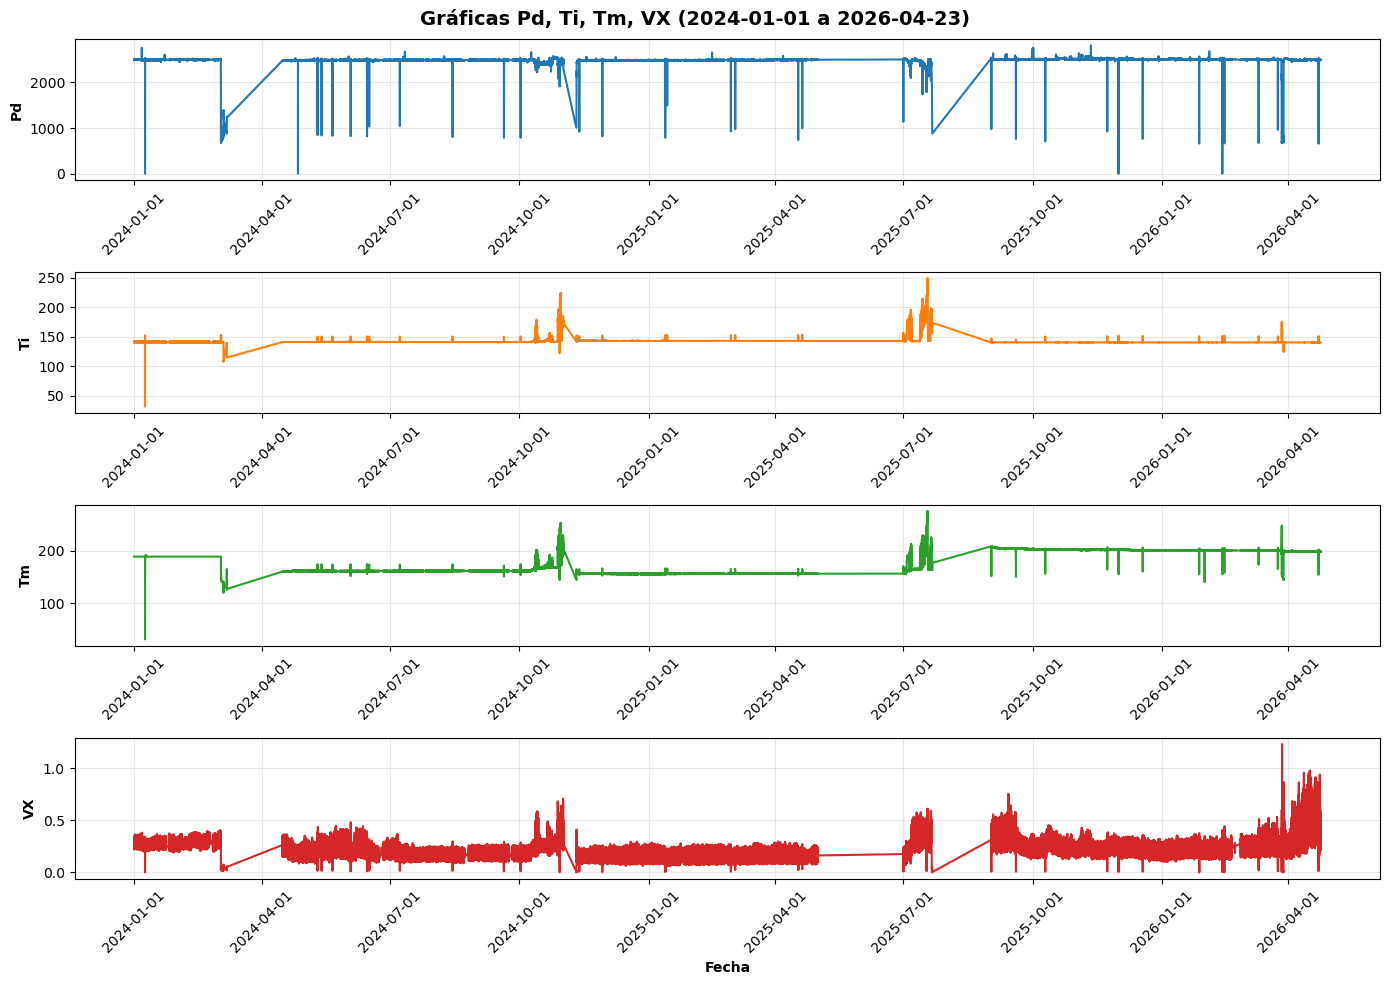

In [168]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.dates as mdates

# Obtener rango de fechas disponibles
fecha_min = df.index.min()
fecha_max = df.index.max()

# Crear widgets para filtro de fechas
date_picker_start = widgets.DatePicker(
    value=fecha_min.date(),
    description='Desde:',
    style={'description_width': '80px'}
)

date_picker_end = widgets.DatePicker(
    value=fecha_max.date(),
    description='Hasta:',
    style={'description_width': '80px'}
)

# Función para actualizar la gráfica
def plot_with_filter(start_date, end_date):
    # Filtrar datos por rango de fechas
    mask = (df.index.date >= start_date) & (df.index.date <= end_date)
    df_filtered = df[mask]
    
    if len(df_filtered) == 0:
        print("No hay datos en el rango de fechas seleccionado")
        return
    
    # Crear figura con 4 subplots
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    fig.suptitle(f'Gráficas Pd, Ti, Tm, VX ({start_date} a {end_date})', fontsize=14, fontweight='bold')
    
    # Pd
    axes[0].plot(df_filtered.index, df_filtered['Pd'], linewidth=1.5, color='#1f77b4')
    axes[0].set_ylabel('Pd', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Ti
    axes[1].plot(df_filtered.index, df_filtered['Ti'], linewidth=1.5, color='#ff7f0e')
    axes[1].set_ylabel('Ti', fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Tm
    axes[2].plot(df_filtered.index, df_filtered['Tm'], linewidth=1.5, color='#2ca02c')
    axes[2].set_ylabel('Tm', fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # VX
    axes[3].plot(df_filtered.index, df_filtered['VX'], linewidth=1.5, color='#d62728')
    axes[3].set_ylabel('VX', fontweight='bold')
    axes[3].set_xlabel('Fecha', fontweight='bold')
    axes[3].grid(True, alpha=0.3)
    axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    
    # Rotar etiquetas de fecha
    for ax in axes:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Crear botón para actualizar
button_update = widgets.Button(
    description='Actualizar Gráfica',
    button_style='info',
    tooltip='Click para actualizar la gráfica'
)

# Manejador del botón
def on_button_click(b):
    plot_with_filter(date_picker_start.value, date_picker_end.value)

button_update.on_click(on_button_click)

# Mostrar controles
print("FILTRO DE FECHAS - Gráficas de Pd, Ti, Tm, VX")
print("=" * 50)
display(widgets.HBox([date_picker_start, date_picker_end]))
display(button_update)

# Mostrar gráfica inicial con todos los datos
plot_with_filter(fecha_min.date(), fecha_max.date())

# Machine learning

In [169]:
df = df.copy()

df['AMA_lag_1']  = df['AMA'].shift(1)
df['AMA_lag_2']  = df['AMA'].shift(2)
df['AMA_lag_5']  = df['AMA'].shift(5)
df['AMA_lag_15'] = df['AMA'].shift(15)
df['AMA_lag_30'] = df['AMA'].shift(30)
df['AMA_mean_30'] = df['AMA'].rolling(30).mean()
df['AMA_std_30'] = df['AMA'].rolling(30).std()

df['AVOV_lag_1']  = df['AVOV'].shift(1)
df['AVOV_lag_2']  = df['AVOV'].shift(2)
df['AVOV_lag_5']  = df['AVOV'].shift(5)
df['AVOV_lag_15'] = df['AVOV'].shift(15)
df['AVOV_lag_30'] = df['AVOV'].shift(30)
df['AVOV_mean_30'] = df['AVOV'].rolling(30).mean()
df['AVOV_std_30'] = df['AVOV'].rolling(30).std()

df['Caudal_lag_1']  = df['Caudal'].shift(1)
df['Caudal_lag_2']  = df['Caudal'].shift(2)
df['Caudal_lag_5']  = df['Caudal'].shift(5)
df['Caudal_lag_15'] = df['Caudal'].shift(15)
df['Caudal_lag_30'] = df['Caudal'].shift(30)
df['Caudal_mean_30'] = df['Caudal'].rolling(30).mean()
df['Caudal_std_30'] = df['Caudal'].rolling(30).std()

df['Ti_lag_31']  = df['Ti'].shift(31)
df['Ti_lag_32']  = df['Ti'].shift(32)
df['Ti_lag_35']  = df['Ti'].shift(35)
df['Ti_lag_45'] = df['Ti'].shift(45)
df['Ti_lag_60'] = df['Ti'].shift(60)
df['Ti_mean_31_60'] = df['Ti'].shift(30).rolling(30).mean()
df['Ti_std_31_60'] = df['Ti'].shift(30).rolling(30).std()

df['Tm_lag_31']  = df['Tm'].shift(31)
df['Tm_lag_32']  = df['Tm'].shift(32)
df['Tm_lag_35']  = df['Tm'].shift(35)
df['Tm_lag_45'] = df['Tm'].shift(45)
df['Tm_lag_60'] = df['Tm'].shift(60)
df['Tm_mean_31_60'] = df['Tm'].shift(30).rolling(30).mean()
df['Tm_std_31_60'] = df['Tm'].shift(30).rolling(30).std()

df['VX_lag_31']  = df['VX'].shift(31)
df['VX_lag_32']  = df['VX'].shift(32)
df['VX_lag_35']  = df['VX'].shift(35)
df['VX_lag_45'] = df['VX'].shift(45)
df['VX_lag_60'] = df['VX'].shift(60)
df['VX_mean_31_60'] = df['VX'].shift(30).rolling(30).mean()
df['VX_std_31_60'] = df['VX'].shift(30).rolling(30).std()


df.dropna(inplace=True)

In [170]:
# Contar NaN por columna
nan_por_columna = df.isna().sum()

print(nan_por_columna)

AMA               0
AMV               0
AVOA              0
AVOV              0
RUN FREQ.         0
Pd                0
Pi                0
Ti                0
Tm                0
VX                0
CRUDP_PRORR       0
GAS_PRORR         0
AGUA_PRORR        0
Caudal            0
AMA_lag_1         0
AMA_lag_2         0
AMA_lag_5         0
AMA_lag_15        0
AMA_lag_30        0
AMA_mean_30       0
AMA_std_30        0
AVOV_lag_1        0
AVOV_lag_2        0
AVOV_lag_5        0
AVOV_lag_15       0
AVOV_lag_30       0
AVOV_mean_30      0
AVOV_std_30       0
Caudal_lag_1      0
Caudal_lag_2      0
Caudal_lag_5      0
Caudal_lag_15     0
Caudal_lag_30     0
Caudal_mean_30    0
Caudal_std_30     0
Ti_lag_31         0
Ti_lag_32         0
Ti_lag_35         0
Ti_lag_45         0
Ti_lag_60         0
Ti_mean_31_60     0
Ti_std_31_60      0
Tm_lag_31         0
Tm_lag_32         0
Tm_lag_35         0
Tm_lag_45         0
Tm_lag_60         0
Tm_mean_31_60     0
Tm_std_31_60      0
VX_lag_31         0


In [171]:
df

,AMA,AMV,AVOA,AVOV,RUN FREQ.,Pd,Pi,Ti,Tm,VX,...,Tm_lag_60,Tm_mean_31_60,Tm_std_31_60,VX_lag_31,VX_lag_32,VX_lag_35,VX_lag_45,VX_lag_60,VX_mean_31_60,VX_std_31_60
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-01 01:00:30,24.283,1718.4,130.4,320.0,42.0,2501.1,628.7,141.8,188.6,0.245,...,188.6,188.600000,0.000000,0.276,0.301,0.289,0.256,0.326,0.278033,0.023532
2024-01-01 01:01:34,24.283,1718.4,130.4,320.0,42.0,2502.4,627.9,141.8,188.6,0.317,...,188.6,188.600000,0.000000,0.277,0.276,0.303,0.268,0.298,0.277233,0.023236
2024-01-01 01:02:30,24.264,1718.4,130.3,320.0,42.0,2502.4,627.9,141.8,188.6,0.317,...,188.6,188.600000,0.000000,0.274,0.277,0.266,0.313,0.267,0.278267,0.023453
2024-01-01 01:03:34,24.283,1718.4,130.4,320.0,42.0,2497.4,628.5,140.0,188.6,0.312,...,188.6,188.600000,0.000000,0.298,0.274,0.301,0.242,0.310,0.277900,0.023022
2024-01-01 01:04:30,24.302,1718.4,130.5,320.0,42.0,2497.4,628.5,140.0,188.6,0.312,...,188.6,188.600000,0.000000,0.299,0.298,0.276,0.259,0.272,0.277867,0.023032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23 21:38:30,24.680,1843.7,127.1,358.0,45.0,2494.8,599.5,140.4,198.2,0.293,...,198.2,198.186667,0.077608,0.352,0.462,0.477,0.329,0.364,0.357033,0.065356
2026-04-23 21:39:32,24.738,1843.7,127.4,358.0,45.0,2494.7,599.2,140.5,198.4,0.275,...,198.2,198.183333,0.079148,0.343,0.352,0.293,0.286,0.282,0.357300,0.065055
2026-04-23 21:40:30,24.757,1843.7,127.5,358.0,45.0,2494.0,599.1,140.5,198.2,0.336,...,198.2,198.183333,0.079148,0.290,0.343,0.340,0.427,0.348,0.359900,0.066219


In [172]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

# Pd 

In [ ]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30'
]

target = 'Pd'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [ ]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

### Regresion lineal

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [ ]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [ ]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    reg_lambda=2,
    reg_alpha=0.1,
    n_estimators=200,
    min_child_weight=1,
    max_depth=3,
    learning_rate=0.01,
    gamma=0.3,
    colsample_bytree=0.7,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### LightGBM

In [ ]:
# Modelo
lgbm = LGBMRegressor(
    boosting_type='gbdt',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

### Catboost

In [ ]:
# Modelo
cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.01,
    depth=3,
    subsample=0.8,
    l2_leaf_reg=2,
    random_seed=42,
    loss_function='RMSE',
    verbose=0
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

### Evaluacion

In [ ]:


evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

In [ ]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

### Grafica

In [ ]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Pd')
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

In [ ]:
inicio = '2026-03-25 17:00:00'
fin    = '2026-04-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Pd')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ti

In [191]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',

    # Datos caudal
    'CRUDP_PRORR',
    'GAS_PRORR',
    'AGUA_PRORR'
]

target = 'Ti'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [192]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 09:46:30
Datos  : 749,022

TEST
Inicio : 2025-12-06 09:47:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,256


### Regresion lineal

In [193]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [194]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
     Feature  Importance
 CRUDP_PRORR    0.122690
  AVOV_lag_5    0.066692
 AMA_mean_30    0.061927
 AVOV_lag_15    0.057826
  AGUA_PRORR    0.057195
  AVOV_lag_2    0.055236
   RUN FREQ.    0.044805
  AVOV_lag_1    0.044430
  AMA_std_30    0.043122
        AVOV    0.042848
         AMV    0.040182
   AMA_lag_2    0.039806
   AMA_lag_5    0.039282
   GAS_PRORR    0.039098
        AVOA    0.037728
   AMA_lag_1    0.037102
 AVOV_lag_30    0.036096
  AMA_lag_15    0.035940
         AMA    0.034764
  AMA_lag_30    0.028367
AVOV_mean_30    0.027661
 AVOV_std_30    0.007202


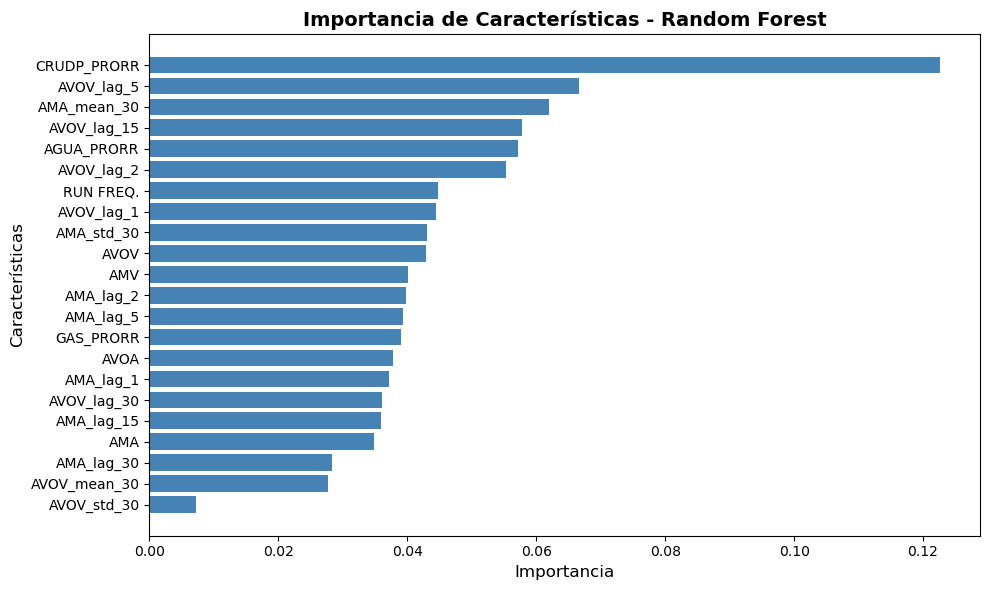


PARTICIPACIÓN PORCENTUAL:
     Feature  Participacion %
 CRUDP_PRORR            12.27
  AVOV_lag_5             6.67
 AMA_mean_30             6.19
 AVOV_lag_15             5.78
  AGUA_PRORR             5.72
  AVOV_lag_2             5.52
   RUN FREQ.             4.48
  AVOV_lag_1             4.44
  AMA_std_30             4.31
        AVOV             4.28
         AMV             4.02
   AMA_lag_2             3.98
   AMA_lag_5             3.93
   GAS_PRORR             3.91
        AVOA             3.77
   AMA_lag_1             3.71
 AVOV_lag_30             3.61
  AMA_lag_15             3.59
         AMA             3.48
  AMA_lag_30             2.84
AVOV_mean_30             2.77
 AVOV_std_30             0.72


In [195]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [196]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [197]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:12:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [198]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,006644 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4188
[LightGBM] [Info] Number of data points in the train set: 749022, number of used features: 22
[LightGBM] [Info] Start training from score 142,885175
[LightGBM] [Warning] feature_

### Catboost

In [199]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 7.1118877	total: 28.1ms	remaining: 14s
1:	learn: 6.8081740	total: 51.6ms	remaining: 12.8s
2:	learn: 6.5505750	total: 78.7ms	remaining: 13s
3:	learn: 6.2748465	total: 98.9ms	remaining: 12.3s
4:	learn: 6.0795624	total: 121ms	remaining: 12s
5:	learn: 5.8661649	total: 145ms	remaining: 11.9s
6:	learn: 5.6861761	total: 168ms	remaining: 11.8s
7:	learn: 5.5288256	total: 191ms	remaining: 11.7s
8:	learn: 5.4101073	total: 213ms	remaining: 11.6s
9:	learn: 5.2892215	total: 235ms	remaining: 11.5s
10:	learn: 5.1985551	total: 259ms	remaining: 11.5s
11:	learn: 5.1182045	total: 283ms	remaining: 11.5s
12:	learn: 5.0465015	total: 304ms	remaining: 11.4s
13:	learn: 4.9811720	total: 326ms	remaining: 11.3s
14:	learn: 4.9265880	total: 347ms	remaining: 11.2s
15:	learn: 4.8657252	total: 370ms	remaining: 11.2s
16:	learn: 4.8258991	total: 391ms	remaining: 11.1s
17:	learn: 4.7773250	total: 413ms	remaining: 11.1s
18:	learn: 4.7437755	total: 433ms	remaining: 11s
19:	learn: 4.7069301	total: 454ms	remaining: 

### Evaluacion

In [200]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 3.071 | R2: -6.514
Random Forest -> RMSE: 0.778 | R2: 0.518
Gradient Boosting -> RMSE: 1.380 | R2: -0.516
XGBoost -> RMSE: 0.838 | R2: 0.441
LightGBM -> RMSE: 0.841 | R2: 0.437
CatBoost -> RMSE: 1.056 | R2: 0.112


In [201]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,3.0712,2.1868,-6.5139,9.4320
1,Random Forest,0.7777,0.2545,0.5182,0.6048
2,Gradient Boosting,1.3796,0.9470,-0.5163,1.9034
3,XGBoost,0.8380,0.3904,0.4406,0.7022
4,LightGBM,0.8408,0.3257,0.4368,0.7070
5,CatBoost,1.0559,0.3176,0.1118,1.1150


### Grafica

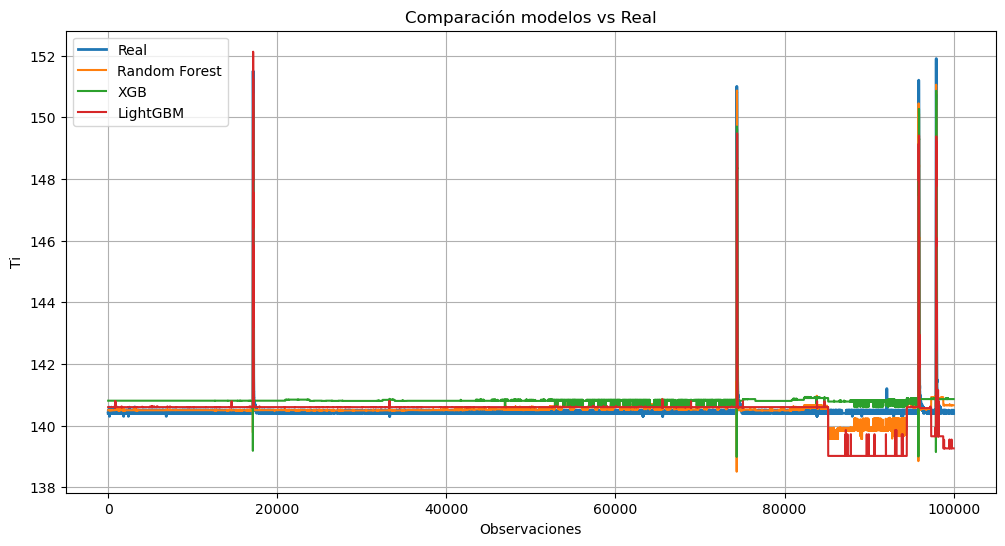

In [206]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Ti')
plt.grid(True)

plt.show()

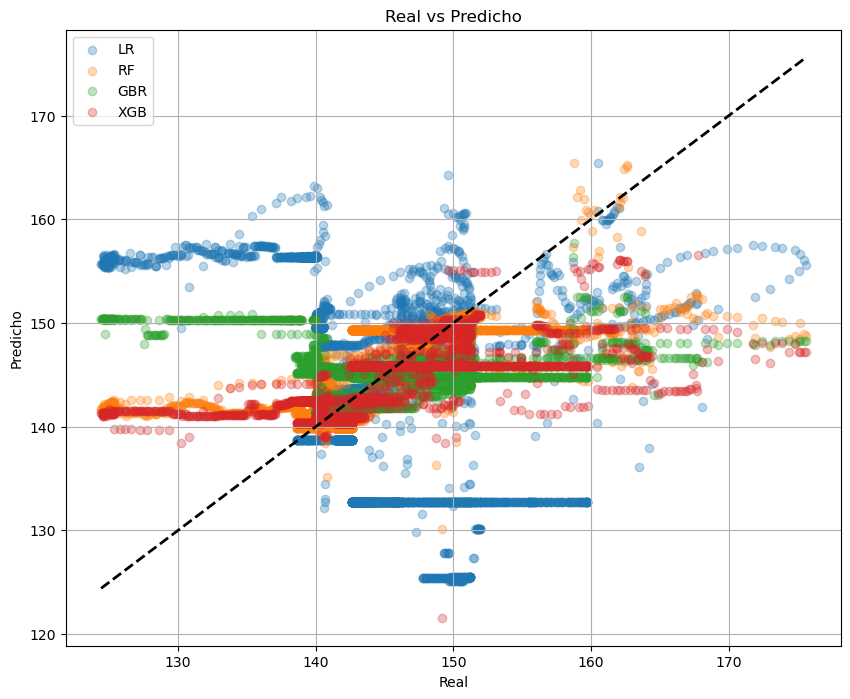

In [203]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [204]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 09:47:30
Fecha final: 2026-04-23 21:42:30


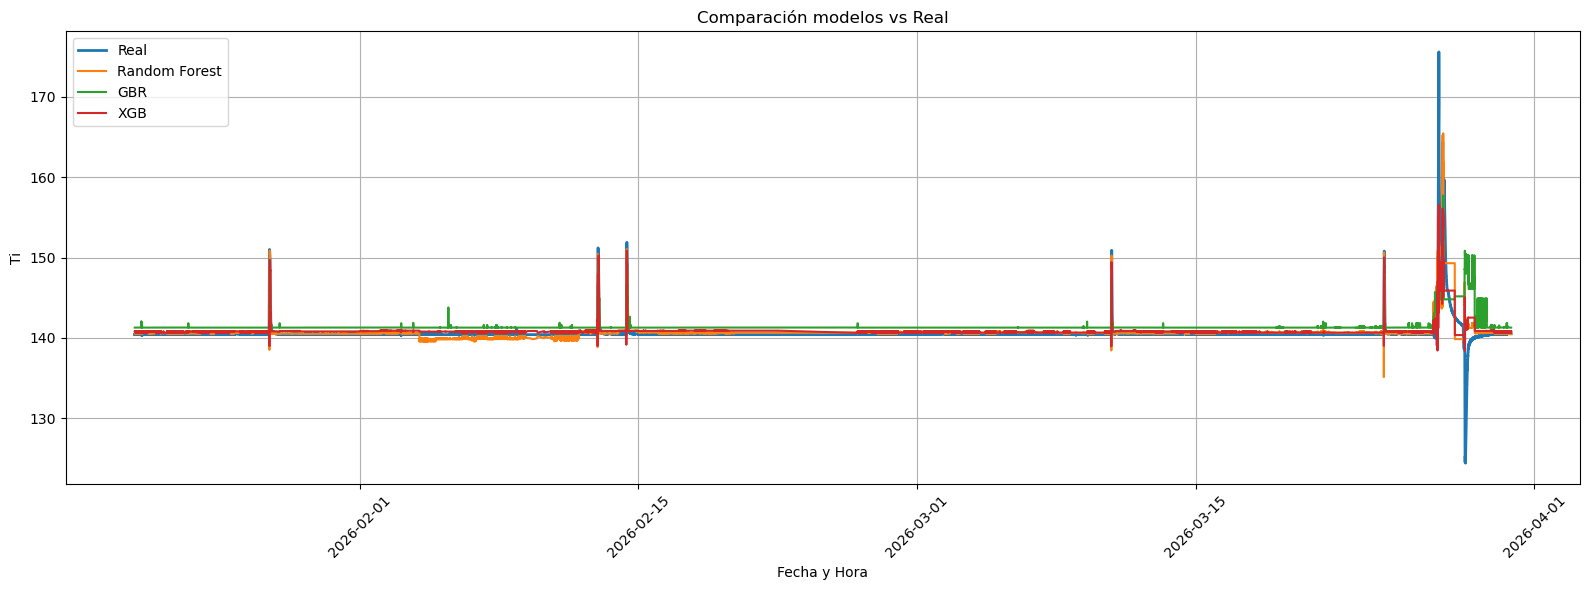

In [205]:
inicio = '2026-01-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Ti')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Tm

In [207]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # Datos caudal
    'CRUDP_PRORR',
    'GAS_PRORR',
    'AGUA_PRORR'

]

target = 'Tm'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [208]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

TRAIN
Inicio : 2024-01-01 01:00:30
Fin    : 2025-12-06 09:46:30
Datos  : 749,022

TEST
Inicio : 2025-12-06 09:47:30
Fin    : 2026-04-23 21:42:30
Datos  : 187,256


### Regresion lineal

In [209]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [210]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST
     Feature  Importance
        AVOA    0.199666
         AMA    0.129005
   AMA_lag_1    0.122671
  AMA_lag_15    0.105056
   AMA_lag_5    0.088563
   AMA_lag_2    0.080662
 AMA_mean_30    0.072918
  AMA_lag_30    0.050537
  AGUA_PRORR    0.027266
  AMA_std_30    0.025847
AVOV_mean_30    0.015909
 CRUDP_PRORR    0.014502
  AVOV_lag_5    0.009680
        AVOV    0.008177
 AVOV_lag_15    0.007973
   RUN FREQ.    0.007508
 AVOV_lag_30    0.007411
  AVOV_lag_1    0.007018
  AVOV_lag_2    0.006780
         AMV    0.006511
   GAS_PRORR    0.005567
 AVOV_std_30    0.000771


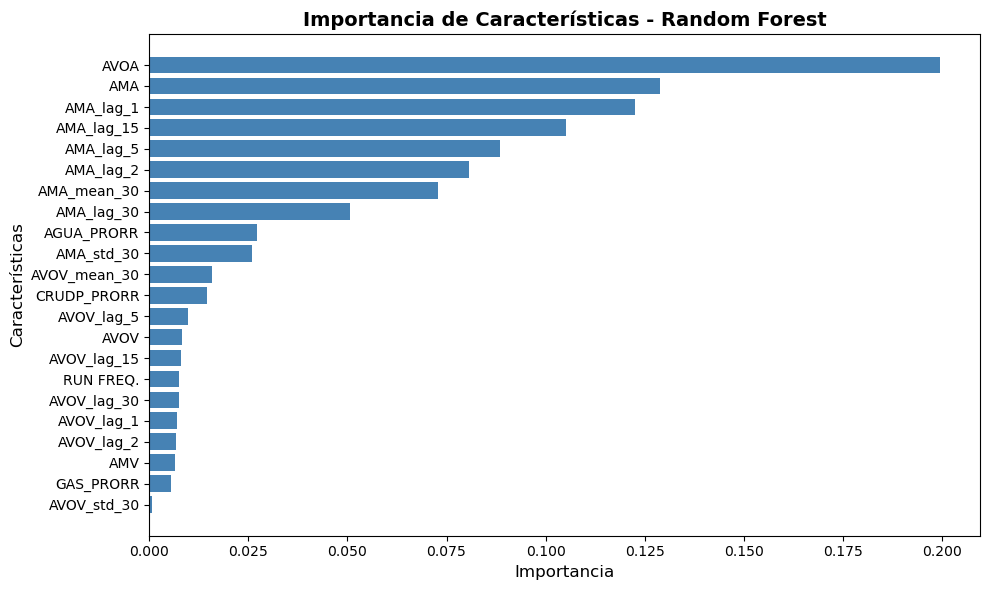


PARTICIPACIÓN PORCENTUAL:
     Feature  Participacion %
        AVOA            19.97
         AMA            12.90
   AMA_lag_1            12.27
  AMA_lag_15            10.51
   AMA_lag_5             8.86
   AMA_lag_2             8.07
 AMA_mean_30             7.29
  AMA_lag_30             5.05
  AGUA_PRORR             2.73
  AMA_std_30             2.58
AVOV_mean_30             1.59
 CRUDP_PRORR             1.45
  AVOV_lag_5             0.97
        AVOV             0.82
 AVOV_lag_15             0.80
   RUN FREQ.             0.75
 AVOV_lag_30             0.74
  AVOV_lag_1             0.70
  AVOV_lag_2             0.68
         AMV             0.65
   GAS_PRORR             0.56
 AVOV_std_30             0.08


In [211]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [212]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [213]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

c:\Users\lggom\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:26:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### LightGBM

In [214]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=0.8 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,007752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4188
[LightGBM] [Info] Number of data points in the train set: 749022, number of used features: 22
[LightGBM] [Info] Start training from score 171,333217
[LightGBM] [Warning] feature_

### Catboost

In [215]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

0:	learn: 17.1426498	total: 24.1ms	remaining: 12s
1:	learn: 15.6878464	total: 48.2ms	remaining: 12s
2:	learn: 14.3969329	total: 72.1ms	remaining: 11.9s
3:	learn: 13.2550430	total: 97.1ms	remaining: 12s
4:	learn: 12.2515087	total: 122ms	remaining: 12.1s
5:	learn: 11.3672810	total: 147ms	remaining: 12.1s
6:	learn: 10.5883759	total: 170ms	remaining: 11.9s
7:	learn: 9.9020069	total: 193ms	remaining: 11.9s
8:	learn: 9.3071615	total: 220ms	remaining: 12s
9:	learn: 8.7708697	total: 244ms	remaining: 12s
10:	learn: 8.3194112	total: 268ms	remaining: 11.9s
11:	learn: 7.9191019	total: 293ms	remaining: 11.9s
12:	learn: 7.5803850	total: 318ms	remaining: 11.9s
13:	learn: 7.2800734	total: 341ms	remaining: 11.9s
14:	learn: 7.0292674	total: 367ms	remaining: 11.9s
15:	learn: 6.8043600	total: 394ms	remaining: 11.9s
16:	learn: 6.5888091	total: 427ms	remaining: 12.1s
17:	learn: 6.4031272	total: 470ms	remaining: 12.6s
18:	learn: 6.2580318	total: 512ms	remaining: 13s
19:	learn: 6.1182335	total: 543ms	remainin

### Evaluacion

In [216]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

Linear Regression -> RMSE: 3.461 | R2: 0.511
Random Forest -> RMSE: 2.480 | R2: 0.749
Gradient Boosting -> RMSE: 15.890 | R2: -9.307
XGBoost -> RMSE: 4.043 | R2: 0.333
LightGBM -> RMSE: 8.344 | R2: -1.842
CatBoost -> RMSE: 9.431 | R2: -2.630


In [217]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

,Modelo,RMSE,MAE,R² Score,MSE
0,Linear Regression,3.4610,2.3605,0.5110,11.9787
1,Random Forest,2.4799,0.8384,0.7490,6.1498
2,Gradient Boosting,15.8904,13.9234,-9.3070,252.5033
3,XGBoost,4.0428,3.1745,0.3329,16.3439
4,LightGBM,8.3440,6.9829,-1.8419,69.6220
5,CatBoost,9.4308,7.8630,-2.6304,88.9392


### Grafica

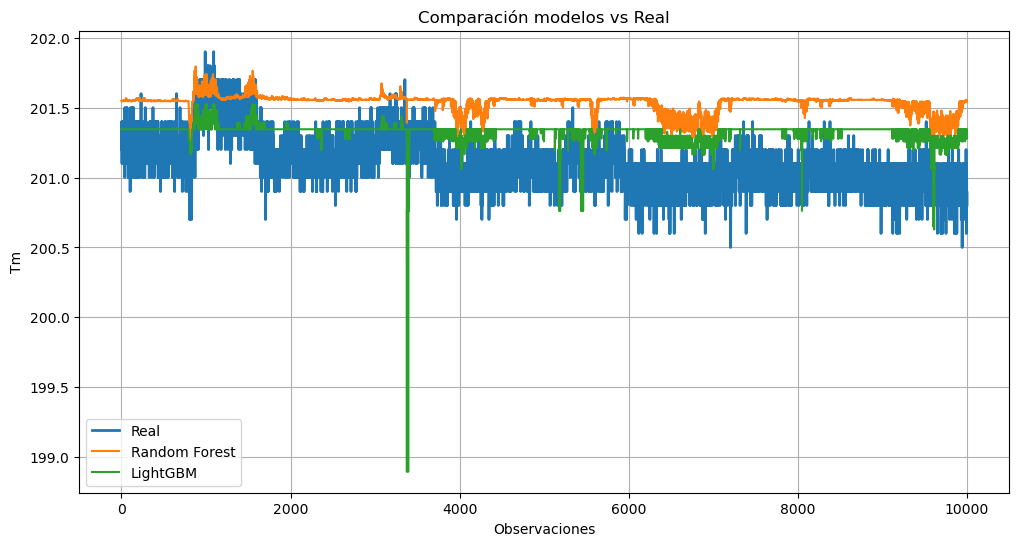

In [218]:
plt.figure(figsize=(12,6))

window_max=10000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('Tm')
plt.grid(True)

plt.show()

c:\Users\lggom\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


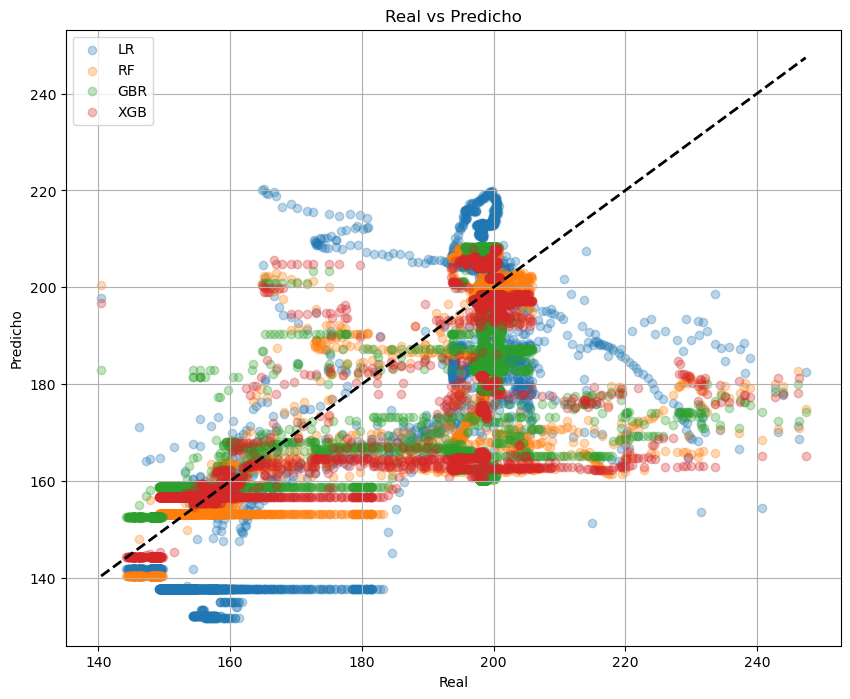

In [219]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [220]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

Fecha inicial: 2025-12-06 09:47:30
Fecha final: 2026-04-23 21:42:30


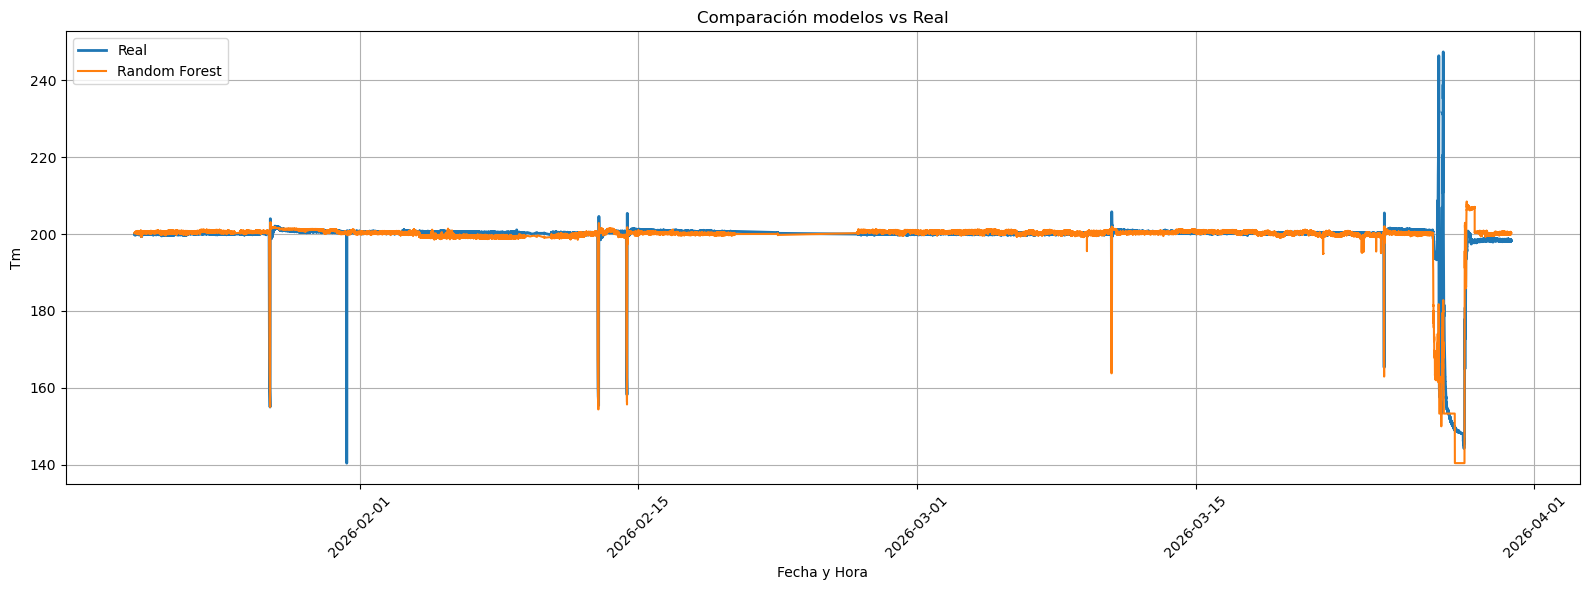

In [223]:
inicio = '2026-01-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
#plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('Tm')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Vx

In [ ]:
features = [
    # variables originales
    'AMA',
    'AMV',
    'AVOA',
    'AVOV',
    'RUN FREQ.',
    # AMA temporal
    'AMA_lag_1',
    'AMA_lag_2',
    'AMA_lag_5',
    'AMA_lag_15',
    'AMA_lag_30',
    'AMA_mean_30',
    'AMA_std_30',
    # AVOV temporal
    'AVOV_lag_1',
    'AVOV_lag_2',
    'AVOV_lag_5',
    'AVOV_lag_15',
    'AVOV_lag_30',
    'AVOV_mean_30',
    'AVOV_std_30',
    # VX temporal
    'VX_lag_31',
    'VX_lag_32',
    'VX_lag_35',
    'VX_lag_45',
    'VX_lag_60',
    'VX_mean_31_60',
    'VX_std_31_60'
]

target = 'VX'

df_model = df[features + [target]].copy()
X = df_model[features]
y = df_model[target]

In [ ]:
# Garantizar que los datos estén ordenados por fecha
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)
print("="*60)

print("TRAIN")

print(f"Inicio : {X_train.index.min()}")
print(f"Fin    : {X_train.index.max()}")
print(f"Datos  : {len(X_train):,}")

print()

print("TEST")

print(f"Inicio : {X_test.index.min()}")
print(f"Fin    : {X_test.index.max()}")
print(f"Datos  : {len(X_test):,}")

print("="*60)

### Regresion lineal

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Random Forest

In [ ]:
rf = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=10,
    random_state=42,
    n_jobs=-1
    )
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# Importancia de las características en el modelo Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE CARACTERÍSTICAS - RANDOM FOREST")
print("=" * 50)
print(feature_importance.to_string(index=False))
print("=" * 50)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Características', fontsize=12)
plt.title('Importancia de Características - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Participación porcentual
feature_importance['Participacion %'] = (feature_importance['Importance'] / feature_importance['Importance'].sum() * 100).round(2)
print("\nPARTICIPACIÓN PORCENTUAL:")
print(feature_importance[['Feature', 'Participacion %']].to_string(index=False))

### Gradient Boosting

In [ ]:
gbr = GradientBoostingRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features=None,
    max_depth=3,
    learning_rate=0.01,
    random_state=42
    )
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

### XGBRegresorr

In [ ]:
# Modelo
xgb = XGBRegressor(
    subsample=0.8,
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=None,
    max_depth=7,
    learning_rate=0.01,
    random_state=42,
    n_jobs=-1
)
# Entrenar
xgb.fit(X_train, y_train)

# Predicción
y_pred_xgb = xgb.predict(X_test)

### LightGBM

In [ ]:
# Modelo
lgbm = LGBMRegressor(
    subsample=0.8,
    reg_lambda=0,
    reg_alpha=0,
    num_leaves=20,
    n_estimators=100,
    min_child_weight=5,
    min_child_samples=20,
    max_depth=5,
    learning_rate=0.05,
    feature_fraction=0.7,
    colsample_bytree=1.0,
    bagging_fraction=0.7,
    random_state=42,
    n_jobs=-1
)
# Entrenar
lgbm.fit(X_train, y_train)
# Predicción
y_pred_lgbm = lgbm.predict(X_test)

### Catboost

In [ ]:
# Modelo
cat = CatBoostRegressor(
    subsample=0.9,
    min_child_samples=20,
    learning_rate=0.1,
    l2_leaf_reg=10,
    iterations=500,
    depth=3,
    colsample_bylevel=0.7,
    border_count=32
)

# Entrenar
cat.fit(X_train, y_train)
# Predicción
y_pred_cat = cat.predict(X_test)

### Evaluacion

In [ ]:
def evaluar(y_true, y_pred, nombre):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{nombre} -> RMSE: {rmse:.3f} | R2: {r2:.3f}")

evaluar(y_test, y_pred_lr,  "Linear Regression")
evaluar(y_test, y_pred_rf,  "Random Forest")
evaluar(y_test, y_pred_gbr, "Gradient Boosting")
evaluar(y_test, y_pred_xgb, "XGBoost")
evaluar(y_test, y_pred_lgbm, "LightGBM")
evaluar(y_test, y_pred_cat, "CatBoost")

In [ ]:
# Crear tabla de evaluación
resultados = []

modelos = {
    "Linear Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gbr,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
    "CatBoost": y_pred_cat
}

for nombre, predicciones in modelos.items():
    mse = mean_squared_error(y_test, predicciones)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    resultados.append({
        "Modelo": nombre,
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R² Score": round(r2, 4),
        "MSE": round(mse, 4)
    })

tabla_evaluacion = pd.DataFrame(resultados)
tabla_evaluacion

### Grafica

In [ ]:
plt.figure(figsize=(12,6))

window_max=100000

plt.plot(y_test.values[:window_max], label='Real', linewidth=2)
#plt.plot(y_pred_lr[:window_max], label='Linear')
plt.plot(y_pred_rf[:window_max], label='Random Forest')
#plt.plot(y_pred_gbr[:window_max], label='GBR')
#plt.plot(y_pred_xgb[:window_max], label='XGB')
#plt.plot(y_pred_lgbm[:window_max], label='LightGBM')
#plt.plot(y_pred_cat[:window_max], label='CatBoost')

plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Observaciones')
plt.ylabel('VX')
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred_lr, alpha=0.3, label='LR')
plt.scatter(y_test, y_pred_rf, alpha=0.3, label='RF')
#plt.scatter(y_test, y_pred_svr, alpha=0.3, label='SVR')
plt.scatter(y_test, y_pred_gbr, alpha=0.3, label='GBR')
plt.scatter(y_test, y_pred_xgb, alpha=0.3, label='XGB')

# Línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)

plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Real vs Predicho')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Fecha inicial:", y_test.index.min())
print("Fecha final:", y_test.index.max())

In [ ]:
inicio = '2026-02-20 17:00:00'
fin    = '2026-03-30 20:00:00'

mask = (y_test.index >= inicio) & (y_test.index <= fin)

plt.figure(figsize=(16,6))

plt.plot(y_test.index[mask], y_test[mask], label='Real', linewidth=2)
plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
plt.plot(y_test.index[mask], y_pred_rf[mask], label='Random Forest')
#plt.plot(y_test.index[mask], y_pred_gbr[mask], label='GBR')
#plt.plot(y_test.index[mask], y_pred_xgb[mask], label='XGB')
# plt.plot(y_test.index[mask], y_pred_lr[mask], label='Linear')
#plt.plot(y_test.index[mask], y_pred_lgbm[mask], label='LightGBM')
#plt.plot(y_test.index[mask], y_pred_cat[mask], label='CatBoost')




plt.legend()
plt.title('Comparación modelos vs Real')
plt.xlabel('Fecha y Hora')
plt.ylabel('VX')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revision cruzada

In [ ]:
# =====================================================
# VALIDACIÓN CRUZADA TEMPORAL Random Forest
# =====================================================

tscv = TimeSeriesSplit(n_splits=5)

results = []

fold = 1

for train_index, test_index in tscv.split(X):

    # división temporal
    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    # =================================================
    # MODELO RANDOM FOREST
    # =================================================

    #model = RandomForestRegressor(n_estimators=100, random_state=42)
    model = RandomForestRegressor(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    random_state=42,
    n_jobs=-1
    )
    # entrenamiento
    model.fit(X_train, y_train)

    # predicción
    y_pred = model.predict(X_test)

    # =================================================
    # MÉTRICAS
    # =================================================

    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # fechas del fold
    train_dates = X_train.index
    test_dates = X_test.index

    # guardar resultados
    results.append({
        'Fold': fold,

        'Train Start': train_dates.min(),
        'Train End': train_dates.max(),

        'Test Start': test_dates.min(),
        'Test End': test_dates.max(),

        'Train Size': len(train_index),
        'Test Size': len(test_index),

        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    # =================================================
    # IMPRESIÓN
    # =================================================

    print("\n" + "="*60)

    print(f"FOLD {fold}")

    print("-"*60)

    print(f"TRAIN:")
    print(f"Inicio: {train_dates.min()}")
    print(f"Fin   : {train_dates.max()}")
    print(f"Datos : {len(train_index):,}")

    print()

    print(f"TEST:")
    print(f"Inicio: {test_dates.min()}")
    print(f"Fin   : {test_dates.max()}")
    print(f"Datos : {len(test_index):,}")

    print()

    print("MÉTRICAS:")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")

    fold += 1

# =====================================================
# RESUMEN FINAL
# =====================================================

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("RESUMEN VALIDACIÓN CRUZADA")
print("="*60)

print(results_df)

print("\nPROMEDIO MÉTRICAS")

print(
    results_df[['MAE', 'RMSE', 'R2']].mean()
)

# Hyperpareter tunning

## Random forest Hypertunning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=10,                      # número de combinaciones aleatorias
    cv=tscv,                        # validación temporal
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Ejecutar búsqueda aleatoria
random_search.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search.best_params_)
best_rf = random_search.best_estimator_

In [ ]:
# Evaluar modelo afinado
y_pred_rf = best_rf.predict(X_test)
evaluar(y_test, y_pred_rf, "Random Forest Tuned")

## Gradient boosting hypertunning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
gbr = GradientBoostingRegressor(
    random_state=42
)
param_dist = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.7, 0.8, 1.0],
    'max_features': ['sqrt', None]
}

In [ ]:
random_search_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_gbr.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_gbr.best_params_)
best_gbr = random_search_gbr.best_estimator_

In [ ]:
y_pred_gbr = best_gbr.predict(X_test)
evaluar(y_test, y_pred_gbr, "Gradient Boosting Tuned")

## XGBRegresorr hypertuning

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

In [ ]:
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_xgb.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_xgb.best_params_)
best_xgb = random_search_xgb.best_estimator_

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)
evaluar(y_test, y_pred_xgb, "XGBoost Tuned")

## LightGBM

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
param_dist = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7, 9],
    'num_leaves': [20, 30, 40, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.01, 0.1, 1.0],
    'reg_lambda': [0, 0.1, 1.0, 10.0],
    'feature_fraction': [0.7, 0.8, 1.0],
    'bagging_fraction': [0.7, 0.8, 1.0]
}

In [ ]:
random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_dist,
    n_iter=20,  # Aumentado a 20 por la mayor cantidad de parámetros
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_lgbm.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_lgbm.best_params_)
best_lgbm = random_search_lgbm.best_estimator_

In [ ]:
y_pred_lgbm = best_lgbm.predict(X_test)
evaluar(y_test, y_pred_lgbm, "LightGBM Tuned")

## Catboost

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
cat = CatBoostRegressor(
    loss_function='RMSE',
    random_state=42,
    verbose=0,
    thread_count=-1
)
param_dist = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7, 9],
    'l2_leaf_reg': [1, 3, 5, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bylevel': [0.7, 0.8, 0.9, 1.0],
    'min_child_samples': [5, 10, 20],
    'border_count': [32, 64, 128],
    'use_best_model': [False, True]
}

In [ ]:
random_search_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
random_search_cat.fit(X_train, y_train)
print("\nMejores parámetros encontrados:\n")
print(random_search_cat.best_params_)
best_cat = random_search_cat.best_estimator_

In [ ]:
y_pred_cat = best_cat.predict(X_test)
evaluar(y_test, y_pred_cat, "CatBoost Tuned")